# Calixto

## Libraries

In [103]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import random

from sklearn.ensemble import RandomForestClassifier
from networkx.algorithms.community import greedy_modularity_communities
from matplotlib.patches import Patch
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier

## Import

In [104]:
raw_network = nx.read_edgelist("input_data/edges_train.edgelist", data=False, nodetype = int, delimiter=',')

In [105]:
G = raw_network.copy()

In [106]:
raw_attributes = pd.read_csv('input_data/attributes.csv')
raw_attributes.info()

<class 'pandas.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   ID         1800 non-null   int64
 1   attribute  1800 non-null   str  
dtypes: int64(1), str(1)
memory usage: 28.3 KB


In [107]:
attrs = raw_attributes.copy()

## Analysis

### Network

In [108]:
# Nodes, edges, density
N, E = G.number_of_nodes(), G.number_of_edges()
print(N, E, nx.density(G), nx.number_of_isolates(G))
lcc = G.subgraph(max(nx.connected_components(G), key=len))
print(nx.number_connected_components(G), lcc.number_of_nodes())

1800 6377 0.003938607868568958 0
1 1800


In [109]:
# Degree distribution
deg = pd.Series(dict(G.degree()))
print(deg.describe())

count    1800.000000
mean        7.085556
std         6.852403
min         1.000000
25%         4.000000
50%         5.000000
75%         7.000000
max        62.000000
dtype: float64


In [110]:
# Degree mean grouped by attritbute
attr_s = pd.Series(nx.get_node_attributes(G, "attr"))
print(deg.groupby(attr_s).mean())

Series([], dtype: float64)


In [111]:
# CLustering
C = nx.average_clustering(G)
print(C)

0.10908775663792247


### Attributes

In [112]:
pos = nx.spring_layout(G, seed=42)  

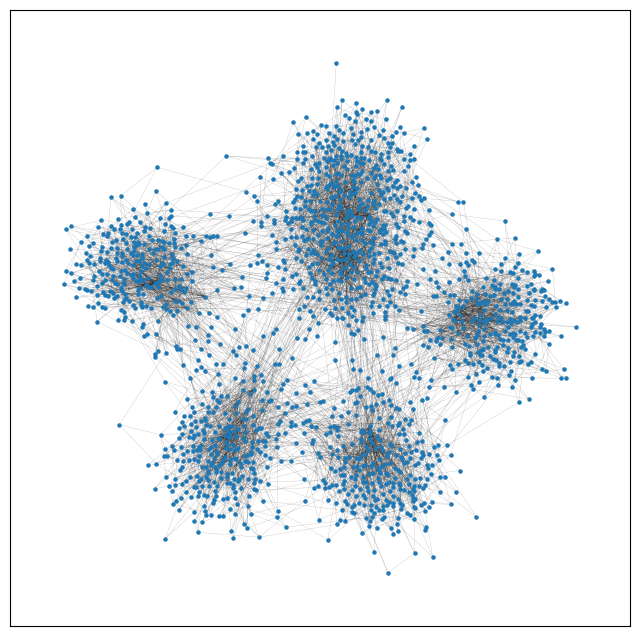

In [113]:
# Draw the original graph
plt.figure(figsize=(8, 8))
nx.draw_networkx_edges(G, pos, width=0.2, alpha=0.3)
nx.draw_networkx_nodes(G, pos, node_size=5)

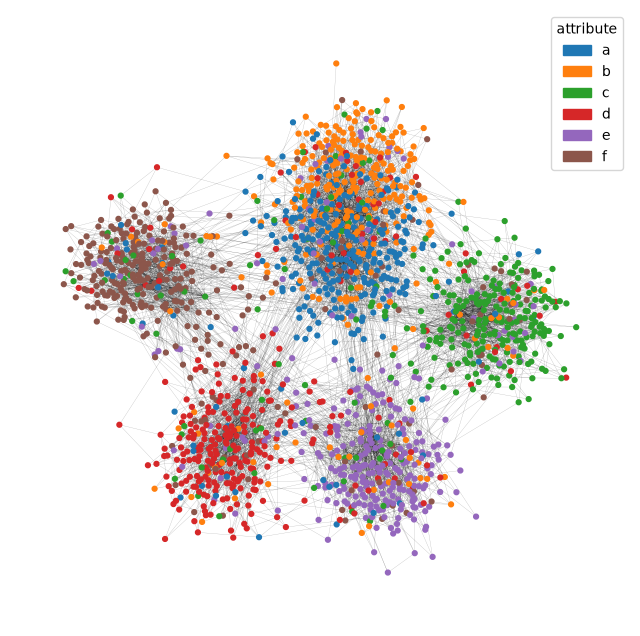

In [114]:
G.add_nodes_from(attrs.ID)                            
nx.set_node_attributes(G, dict(zip(attrs.ID, attrs.attribute)), "attr")

cats = sorted(attrs.attribute.unique())               
cmap = plt.get_cmap("tab10")
color_of = {c: cmap(i) for i, c in enumerate(cats)}
node_colors = [color_of[G.nodes[n]["attr"]] for n in G.nodes()]

plt.figure(figsize=(8, 8))
nx.draw_networkx_edges(G, pos, width=0.2, alpha=0.3)
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=12)
plt.legend(handles=[Patch(color=color_of[c], label=c) for c in cats], title="attribute")
plt.axis("off"); plt.show()

In [115]:
# Use modularity communities to segment the network
communities = list(greedy_modularity_communities(G, resolution=0.8))

print(communities)
print(len(communities))

[frozenset({3, 4, 6, 11, 1036, 1039, 1047, 34, 35, 36, 37, 44, 47, 48, 1078, 1080, 1081, 58, 1083, 59, 61, 1088, 65, 1090, 70, 71, 1096, 1103, 79, 1104, 1109, 1111, 90, 92, 93, 1120, 1121, 1124, 1126, 1127, 1129, 108, 1137, 1138, 115, 1140, 1141, 1142, 121, 122, 125, 1161, 141, 149, 150, 154, 1179, 157, 1182, 160, 1187, 163, 171, 174, 176, 180, 181, 184, 1208, 1210, 1213, 1219, 196, 202, 1230, 208, 210, 1236, 214, 222, 1251, 1252, 1258, 237, 1263, 1265, 244, 1269, 1270, 248, 250, 251, 252, 1278, 258, 259, 262, 1289, 269, 280, 1309, 1315, 1316, 293, 294, 295, 1322, 298, 1327, 306, 308, 309, 314, 315, 1340, 1344, 324, 325, 327, 1352, 329, 332, 334, 336, 1361, 337, 1365, 348, 349, 353, 1383, 359, 370, 1397, 374, 1399, 379, 1408, 1415, 1416, 1417, 393, 1420, 397, 1422, 399, 401, 1425, 1427, 1429, 409, 413, 1439, 1440, 416, 421, 1449, 431, 1459, 1460, 438, 1467, 460, 1485, 1490, 469, 1497, 1499, 478, 479, 482, 484, 1508, 490, 1515, 493, 497, 498, 1522, 1524, 506, 1534, 1536, 514, 515, 520, 

In [116]:
# Iterate over the communities to assign colors
community_of = {}
for community_id, community in enumerate(communities):
    for node in community:
        community_of[node] = community_id

node_colors = [community_of[node] for node in G.nodes()]

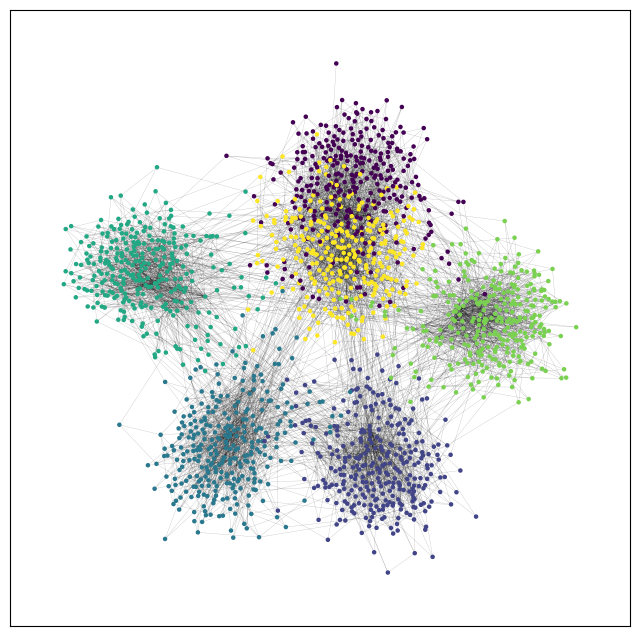

In [117]:
# Draw the original graph
plt.figure(figsize=(8, 8))
nx.draw_networkx_edges(G, pos, width=0.2, alpha=0.3)
nx.draw_networkx_nodes(G, pos, node_size=5, node_color=node_colors)

### Link prediction

In [118]:
# Remove 10% of the dataset
random.seed(42)

edges = list(G.edges())
nodes = list(G.nodes())

n_hide = int(0.1 * len(edges))
hidden = random.sample(edges, n_hide)

G_feat = G.copy()
G_feat.remove_edges_from(hidden)

neg = set()

while len(neg) < n_hide:
    u, v = random.sample(nodes, 2)
    if not G.has_edge(u, v):
        neg.add((min(u, v), max(u, v)))

# communities computed ONCE, on G_feat (not on G) → no leakage
comm_of = {n: i for i, c in enumerate(greedy_modularity_communities(G_feat, resolution=1.5))
           for n in c}

def features(Gf, u, v, comm_of):
    return {
        "common_nb":   len(list(nx.common_neighbors(Gf, u, v))),
        "jaccard":     next(nx.jaccard_coefficient(Gf, [(u, v)]))[2],
        "adamic_adar": next(nx.adamic_adar_index(Gf, [(u, v)]))[2],
        "pref_attach": Gf.degree(u) * Gf.degree(v),
        "same_attr":   int(Gf.nodes[u]["attr"] == Gf.nodes[v]["attr"]),
        "same_comm":   int(comm_of[u] == comm_of[v]),
    }

pairs  = hidden + list(neg)
Y      = np.array([1]*len(hidden) + [0]*len(neg))
X      = pd.DataFrame([features(G_feat, u, v, comm_of) for u, v in pairs])

In [119]:
pd.Series({f: roc_auc_score(Y, X[f]) for f in X.columns}).sort_values(ascending=False)

same_comm      0.853218
pref_attach    0.683956
same_attr      0.678964
adamic_adar    0.672859
common_nb      0.672178
jaccard        0.669271
dtype: float64

In [120]:
# Split data 
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.2, stratify=Y, random_state=42)

### Models

In [121]:
clf = LogisticRegression(random_state=0, C=2.0)
clf.fit(X_train, y_train)

scores = cross_val_score(clf, X_train, y_train, cv=5)
print("CV: %0.3f ± %0.2f" % (scores.mean(), scores.std()))

clf.fit(X_train, y_train)
print("Test accuracy: %0.3f" % clf.score(X_test, y_test))

CV: 0.853 ± 0.03
Test accuracy: 0.867


In [122]:
dtc = DecisionTreeClassifier(max_depth=2)
dtc.fit(X_train,y_train)

scores = cross_val_score(dtc, X_train, y_train, cv=5)
print("CV: %0.3f ± %0.2f" % (scores.mean(), scores.std()))

dtc.fit(X_train, y_train)
print("Test accuracy: %0.3f" % dtc.score(X_test, y_test))

CV: 0.847 ± 0.03
Test accuracy: 0.871


In [123]:
# Random forest
models = {
    "Decision tree": DecisionTreeClassifier(max_depth=2, random_state=42),
    "Random forest": RandomForestClassifier(n_estimators=200, max_depth=5, random_state=42),
}

for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=5)
    model.fit(X_train, y_train)
    print(f"{name}: CV {scores.mean():.3f} ± {scores.std():.3f} | "
          f"Test {model.score(X_test, y_test):.3f}")

# Which features does the forest rely on?
rf = models["Random forest"]
print(pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False).round(3))

Decision tree: CV 0.847 ± 0.030 | Test 0.871
Random forest: CV 0.855 ± 0.031 | Test 0.855
same_comm      0.532
pref_attach    0.155
jaccard        0.084
adamic_adar    0.084
same_attr      0.077
common_nb      0.069
dtype: float64


In [124]:
for d in [2, 3, 5, 8, None]:
    dt = cross_val_score(DecisionTreeClassifier(max_depth=d, random_state=42), X_train, y_train, cv=5).mean()
    rf = cross_val_score(RandomForestClassifier(n_estimators=200, max_depth=d, random_state=42), X_train, y_train, cv=5).mean()
    print(f"depth={d}:  DT {dt:.3f} | RF {rf:.3f}")

depth=2:  DT 0.847 | RF 0.851
depth=3:  DT 0.847 | RF 0.851
depth=5:  DT 0.844 | RF 0.855
depth=8:  DT 0.830 | RF 0.837
depth=None:  DT 0.806 | RF 0.838


In [128]:
from sklearn.ensemble import (RandomForestClassifier, VotingClassifier,
                              StackingClassifier, GradientBoostingClassifier)
from sklearn.linear_model import LogisticRegression

dt = DecisionTreeClassifier(max_depth=2, random_state=42)
rf = RandomForestClassifier(n_estimators=200, max_depth=5, random_state=42)

models = {
    "Voting (DT+RF)":   VotingClassifier([("dt", dt), ("rf", rf)], voting="soft"),
    "Stacking (DT+RF)": StackingClassifier([("dt", dt), ("rf", rf)],
                                           final_estimator=LogisticRegression()),
    "Boosting":         GradientBoostingClassifier(n_estimators=100, max_depth=2, random_state=42),
}

for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=5)
    print(f"{name}: CV {scores.mean():.3f} ± {scores.std():.3f}")

Voting (DT+RF): CV 0.849 ± 0.032
Stacking (DT+RF): CV 0.849 ± 0.032
Boosting: CV 0.843 ± 0.036


## Kaggle

In [125]:
solution = pd.read_csv("input_data/solutionInput.csv")              # ID, int1, int2
comm_G = {n: i for i, c in enumerate(greedy_modularity_communities(G, resolution=0.8)) for n in c}

X_sol = pd.DataFrame([features(G, u, v, comm_G)
                      for u, v in zip(solution.int1, solution.int2)])
X_sol = X_sol[X_train.columns]                            # same columns, same order as training

In [126]:
solution["prediction"] = dtc.predict(X_sol)
print(solution.prediction.mean())                         # sanity check: should be near 0.5
solution[["ID", "prediction"]].to_csv("output_kaggle/submission_calixto.csv", index=False)

0.5459039548022598
